In [115]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License


## Time to measure qubits

In [1]:
import qiskit
from qiskit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))

# Disregard any warning on the following imports
from _helpers.circuit_submitter import CircuitSubmitter

In [2]:
device_name = "noisy_sim_with_shots"
submitter = CircuitSubmitter("time_to_measure_qubits", device_name)
# Uncomment the following lines if you are using a noisy simulator and would like to change the noise model
# noise_model = None
# submitter.backend.device.noisy_sim.set_options(noise_model=noise_model)

In [51]:
circuits = []
total_repetitions = 400

idle_gates_per_measurement = 20
number_of_idle_gates = [
    idle_gates_per_measurement * i
    for i in range(1, total_repetitions, total_repetitions // 10)
]
# Here we add 20 identity gates due to noise model restrictions
# The noise is determined due to pre-selected gate times
# In the emulation, the gate times are not taken into account so we must add the relevant amount of
# noise for each measurement. This is only required in emulation. In practice on hardware, one can simply leave
# the qubit 0 idle for time taken to measure qubit 1.

repetitions = [i for i in range(1, total_repetitions, total_repetitions // 10)]
for repetition in repetitions:
    circuit = qiskit.QuantumCircuit(QuantumRegister(2), ClassicalRegister(2))
    circuit.sx(0)
    circuit.sx(0)
    circuit.barrier()
    for _ in range(repetition):
        for _ in range(idle_gates_per_measurement):
            circuit.id(0)
            circuit.barrier(0, 0)
        circuit.measure(1, 1)
        circuit.barrier()
    circuit.measure(0, 0)
    circuits.append(circuit)

In [52]:
shots = 1024
tasks = submitter.submit_circuits(
    shots=shots,
    qasm_strs=[c.qasm() for c in circuits],
    skip_asking=True,
    skip_transpilation=True,
)

Ready to run 10 circuits on noisy_sim_with_shots with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted


In [53]:
all_counts = submitter.retrieve_counts([task.id for task in tasks], wait=True)

2024-07-26 16:57:43 All circuits are finished


In [54]:
counts = []
for counts_this_circuit in all_counts:
    for key in ['00', '01', '10', '11']:
        if key not in counts_this_circuit.keys():
            counts_this_circuit[key] = 0
    counts.append(counts_this_circuit['10'] + counts_this_circuit['11'])

[0.95605469 0.44238281 0.20996094 0.07421875 0.03320312 0.01171875
 0.00488281 0.00488281 0.         0.        ]


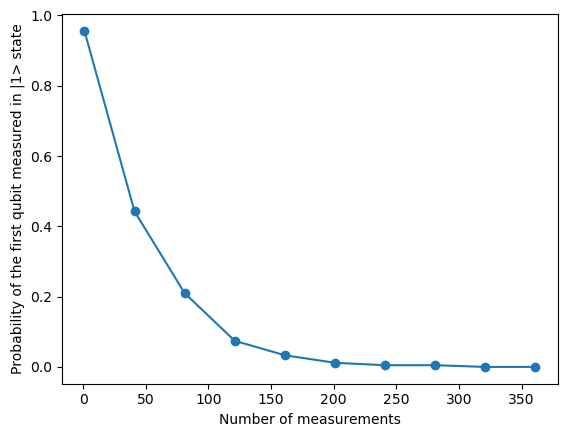

In [55]:
# Convert counts into probabilities and plot curve
probabilities = np.array(counts) / shots
print(probabilities)
plt.plot(repetitions, probabilities, "-o")
plt.xlabel(f"Number of measurements")
plt.ylabel("Probability of the first qubit measured in |1> state")
plt.savefig(submitter.benchmark_path + "/plot.png")
plt.show()

In [56]:
def exp_func(x, amp, dr):
    return amp * np.exp(x * -1 / dr)

In [76]:
# Assume T1 time is known, either from device documentation or obtained by measurements
T1 = 50  # microseconds

# Fit for decay curve and calculate estimated gate time
T1_measurement, pcov = curve_fit(exp_func, repetitions, probabilities, p0=[1, 1000], method='trf')


print(f"The T1 = {T1_measurement[1]} in terms of the number of measurements")
print(f"Therefore, the measurement time is {1/T1_measurement[1]} in terms of the T1 time")

# To get the measurement time in terms of t_n1q, we need T_n1q. This is obtained from T1 measurements
T1_n1q = 1035.293779962006 # in terms of number of idle gates

measurement_time_in_terms_of_idle_gate_time = T1_n1q / T1_measurement[1]

result_str = f"The measurement time in terms of number of single qubit gates = {measurement_time_in_terms_of_idle_gate_time}"

with open(submitter.benchmark_path + "/results.txt", "w+") as f:
    f.write(result_str)
print(result_str)

The T1 = 50.89920628272903 in terms of the number of measurements
Therefore, the measurement time is 0.019646671785907927 in terms of the T1 time
The measurement time in terms of number of single qubit gates = 20.340077096905514


/tmp/ipykernel_8098/3002724832.py:2: RuntimeWarning: overflow encountered in exp
  return amp * np.exp(x * -1 / dr)
